**Yield Curve PCA Analysis**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fbourgey/fre-gy-7773-mlfe/blob/main/07_yield_curve_pca.ipynb)

- Given yields $y_t(\tau_j)$ for dates $t\in\{1,\ldots,T\}$ and 
maturities $\tau_j$, $j\in\{1,\ldots,M\}$.

- **Step 1**: Data matrix and centering
$$
    Y \in \mathbb{R}^{T \times M}, \quad Y_{t,j} = y_t(\tau_j),
    \quad \mu_j = \frac{1}{T} \sum_{t=1}^T Y_{t,j}, \quad X_{t,j} = Y_{t,j} - \mu_j.
$$ 

- **Step 2**: Covariance matrix across maturities

$$
    \Sigma = \frac{1}{T-1} X^\top X \in \mathbb{R}^{M \times M}.
$$

- **Step 3**: Eigen-decomposition (PCA). Loadings across the curve.

    $$
        \Sigma u_k = \lambda_k u_k, \qquad k\in\{1,\ldots,M\},
    $$
    where: 
    - $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_M \geq 0$ the eigenvalues
    - $u_k \in \mathbb{R}^M$ are the eigenvectors (loadings). They represent
        the shape of the yield curve components.

- **Step 4**: Scores (factor time series)

    $$
        f_k(t) = X_{t,\cdot} \, u_k, \quad t=1,\ldots,T.
    $$

- **Step 5**: Rank-$K$ reconstruction. Let $U = [u_1, \ldots, u_M] \in \mathbb{R}^{M \times M}$
and $F = [f_1, \ldots, f_M] \in \mathbb{R}^{T \times M}$.

    $$
        Y^{(K)} = \mathbf{1} \mu^{\top} + \sum_{k=1}^K f_k \, u_k^\top \in \mathbb{R}^{T \times M}
    $$

- **Step 6**: Explained variance

    $$
        \text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^M \lambda_j}.
    $$

- **Step 7**: Interpretation of components

    - Level (1st component, $u_1$): Parallel shifts in the yield curve.
    - Slope (2nd component, $u_2$): Changes in the steepness of the yield curve.
    - Curvature (3rd component, $u_3$): Changes in the curvature of the yield curve.

## Imports

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import numpy as np
import pandas as pd
import datetime as dt
from pandas_datareader import data as web
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

## Load data

In [21]:
start = dt.datetime(2010, 1, 1)
end = dt.datetime.today()

# Constant-maturity Treasury series from FRED
fred_tickers = [
    "DGS1MO",
    "DGS3MO",
    "DGS6MO",
    "DGS1",
    "DGS2",
    "DGS3",
    "DGS5",
    "DGS7",
    "DGS10",
    "DGS20",
    "DGS30",
]

n_mats = len(fred_tickers)

# Load data from local CSV or download from FRED
# Set to False to download from FRED
load = True
if load:
    yields = pd.read_csv("data/yields.csv", index_col=0, parse_dates=True)
else:
    yields = pd.concat(
        [web.DataReader(t, "fred", start, end) for t in fred_tickers], axis=1
    )
df_yields = yields.dropna()
df_yields.columns = fred_tickers
df_yields /= 100.0  # convert to decimals

In [22]:
df_yields.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,
2010-01-04,0.0005,0.0008,0.0018,0.0045,0.0109,0.0166,0.0265,0.0336,0.0385,0.0460,0.0465
2010-01-05,0.0003,0.0007,0.0017,0.0041,0.0101,0.0157,0.0256,0.0328,0.0377,0.0454,0.0459
2010-01-06,0.0003,0.0006,0.0015,0.0040,0.0101,0.0160,0.0260,0.0333,0.0385,0.0463,0.0470
2010-01-07,0.0002,0.0005,0.0016,0.0040,0.0103,0.0162,0.0262,0.0333,0.0385,0.0462,0.0469
2010-01-08,0.0002,0.0005,0.0015,0.0037,0.0096,0.0156,0.0257,0.0331,0.0383,0.0461,0.0470


Prepare data

In [23]:
Y =  df_yields.values # shape (T, M)
mu = np.mean(Y, axis=0)  # shape (M,)
X = Y - mu  # centered data
cov_X = np.cov(X.T)  # (M, M) covariance matrix

In [24]:
print(cov_X.shape)

(11, 11)


Perform PCA

In [25]:
U, S, U_transpose = np.linalg.svd(cov_X)
explained_variance = S / np.sum(S)
print("Explained variance ratio:", explained_variance)

Explained variance ratio: [9.13643395e-01 7.13927489e-02 1.27307151e-02 1.56822810e-03
 3.16376241e-04 1.76956093e-04 8.75196645e-05 4.28756638e-05
 2.29010843e-05 1.21404316e-05 6.14350162e-06]


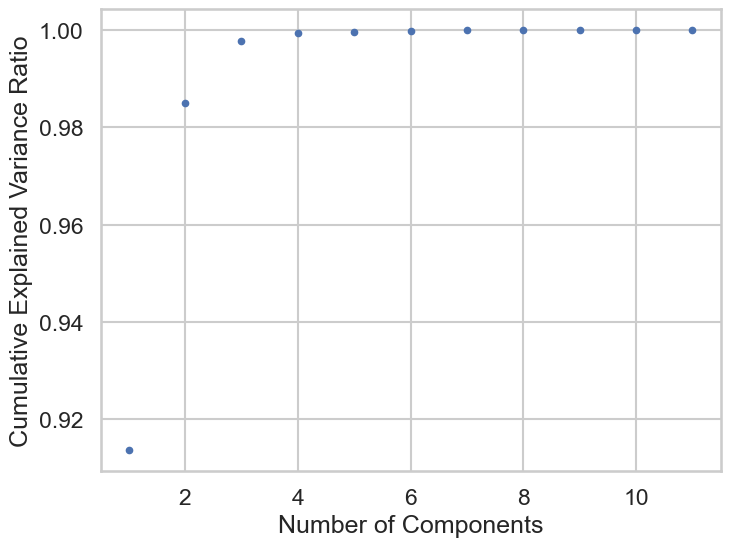

In [26]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, n_mats + 1), np.cumsum(explained_variance), ".")
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance Ratio")
plt.show()

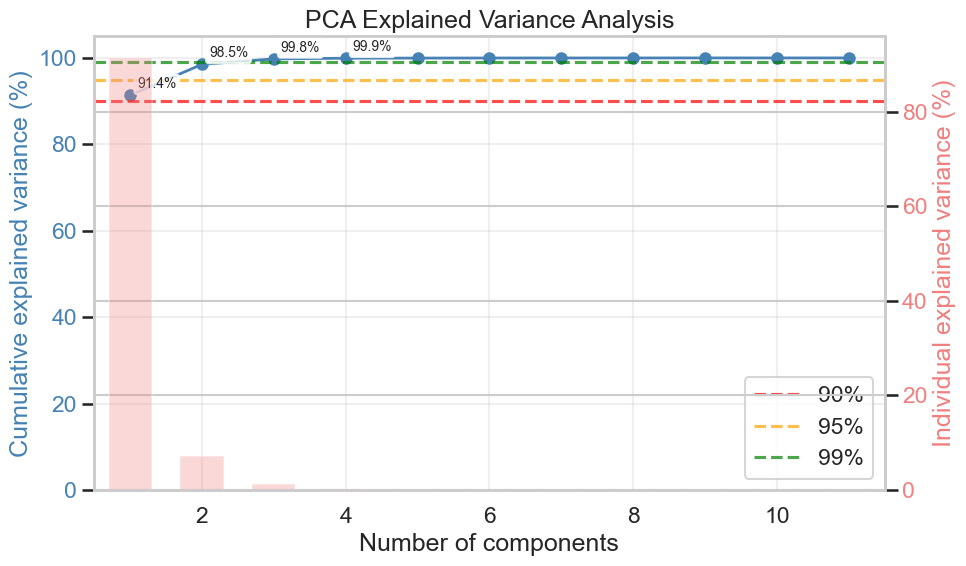

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

# plot cumulative explained variance with better styling
ax.plot(
    range(1, n_mats + 1),
    100 * explained_variance.cumsum(),
    "o-",
    linewidth=2,
    markersize=8,
    color="steelblue",
)

# add individual explained variance as bars
ax2 = ax.twinx()
ax2.bar(
    range(1, n_mats + 1),
    100 * explained_variance,
    alpha=0.3,
    color="lightcoral",
    width=0.6,
    label="Individual",
)

# add horizontal reference lines
ax.axhline(y=90, color="red", linestyle="--", alpha=0.7, label="90%")
ax.axhline(y=95, color="orange", linestyle="--", alpha=0.7, label="95%")
ax.axhline(y=99, color="green", linestyle="--", alpha=0.7, label="99%")

# annotations for first few components
for i in range(min(4, n_mats)):
    cumvar = 100 * explained_variance[: i + 1].sum()
    ax.annotate(
        f"{cumvar:.1f}%",
        xy=(i + 1, cumvar),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.8},
    )

# styling
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)", color="steelblue")
ax2.set_ylabel("Individual explained variance (%)", color="lightcoral")
ax.set_title("PCA Explained Variance Analysis")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_xlim(0.5, n_mats + 0.5)
ax.set_ylim(0, 105)

# color the y-axis labels to match the data
ax.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="lightcoral")

plt.tight_layout()
plt.show()

In [28]:
# print summary statistics
print(
    f"First 3 components explain {np.sum(explained_variance[:3])*100:.2f}% of variance"
)
print(
    "Components needed for 95% variance: "
    f"{np.argmax(np.cumsum(explained_variance) >= 0.95) + 1}"
)
print(
    "Components needed for 99% variance: "
    f"{np.argmax(np.cumsum(explained_variance) >= 0.99) + 1}"
)

First 3 components explain 99.78% of variance
Components needed for 95% variance: 2
Components needed for 99% variance: 3


In [29]:
list_dates = df_yields.index.tolist()

Pick a specific date

In [30]:
date = dt.datetime(2025, 9, 24)

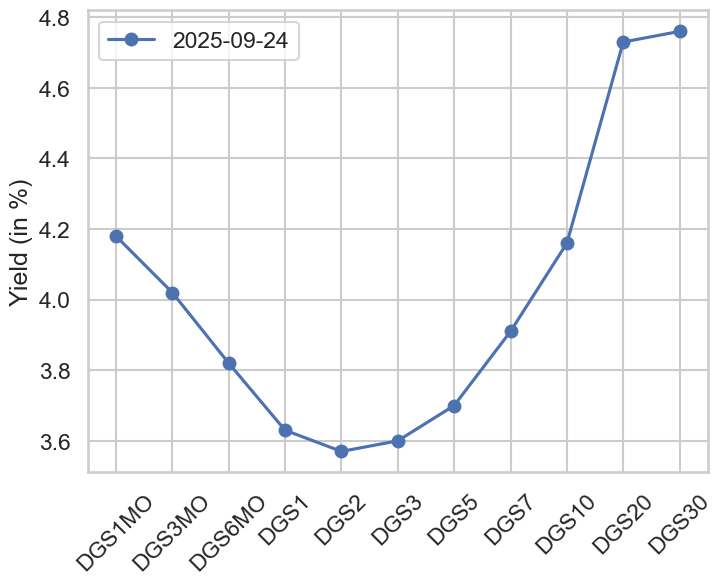

In [31]:
fig, ax = plt.subplots()
ax.plot(
    fred_tickers,
    100 * df_yields.loc[date],
    "o-",
    label=date.strftime("%Y-%m-%d"),
)
ax.legend()
ax.set_ylabel("Yield (in %)")
ax.tick_params(axis="x", rotation=45)
plt.show()

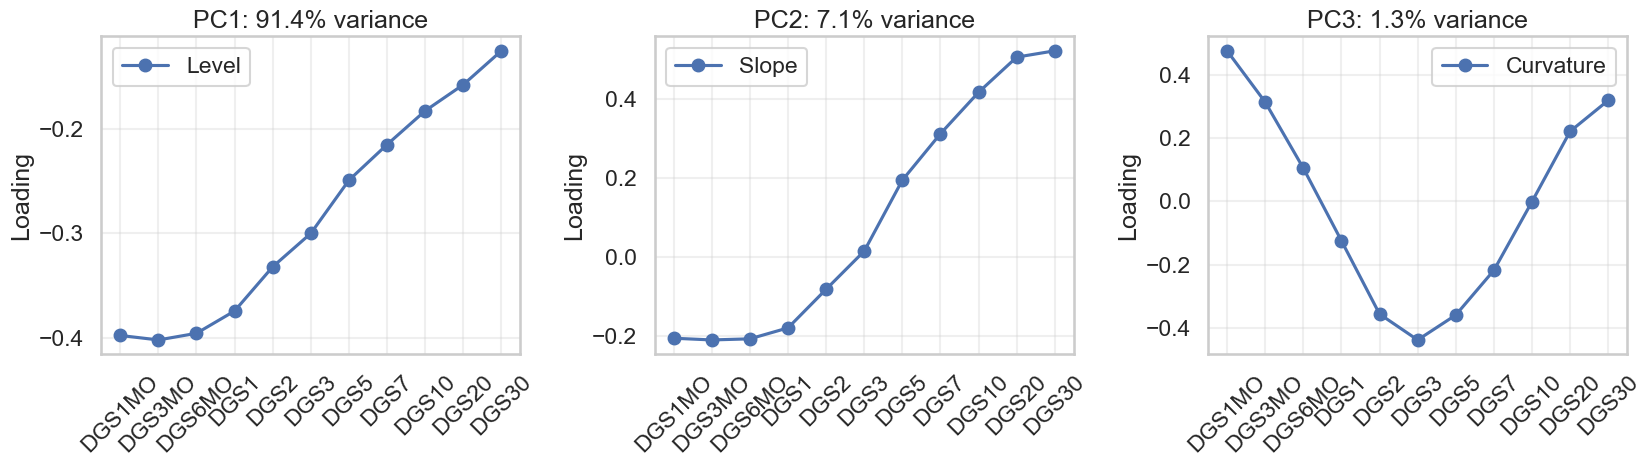

In [32]:
# Compute factor scores (projections onto principal components)
F = X @ U  # shape (T, M) - factor time series

components = ["Level", "Slope", "Curvature"]

# Plot the first 3 principal component loadings (shapes)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, factor in enumerate(components):
    axes[i].plot(fred_tickers, U[:, i], "o-", label=factor)
    axes[i].set_title(f"PC{i + 1}: {explained_variance[i]:.1%} variance")
    axes[i].set_ylabel("Loading")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
plt.tight_layout()
plt.show()

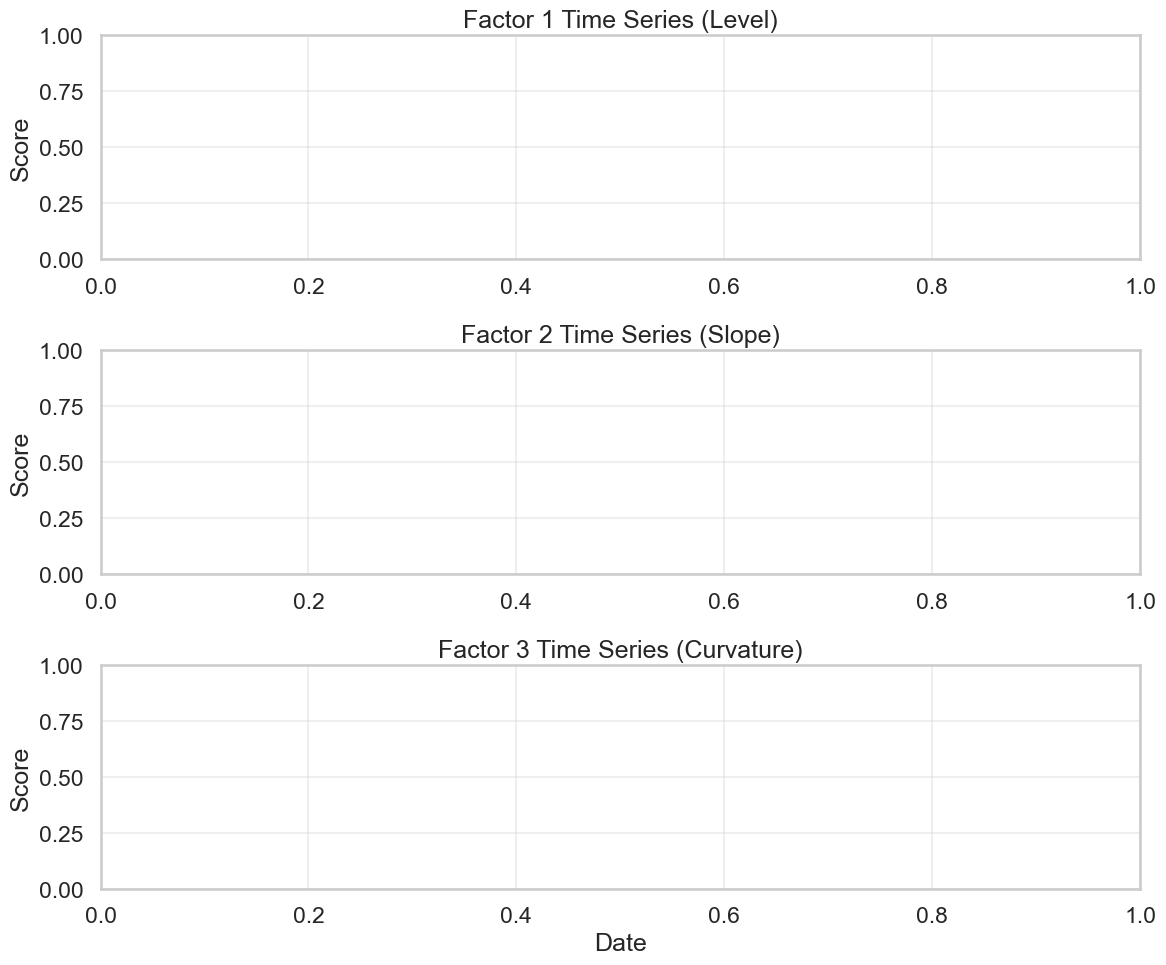

In [33]:
# Plot factor time series (scores over time)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i in range(3):
    # TODO
    axes[i].set_title(f"Factor {i + 1} Time Series ({components[i]})")
    axes[i].set_ylabel("Score")
    axes[i].grid(True, alpha=0.3)
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

Reconstruct yield curve using $K$ components and compare with actual

In [ ]:
K = 3  # number of components to use

date = dt.datetime(2025, 9, 24)  # pick a date for reconstruction
date_idx = df_yields.index.get_loc(date)

# original yield curve
y_actual = #TODO
y_actual = np.asarray(y_actual)

# reconstructed yield curve
y_reconstructed = #TODO

In [16]:
y_actual = np.asarray(y_actual)

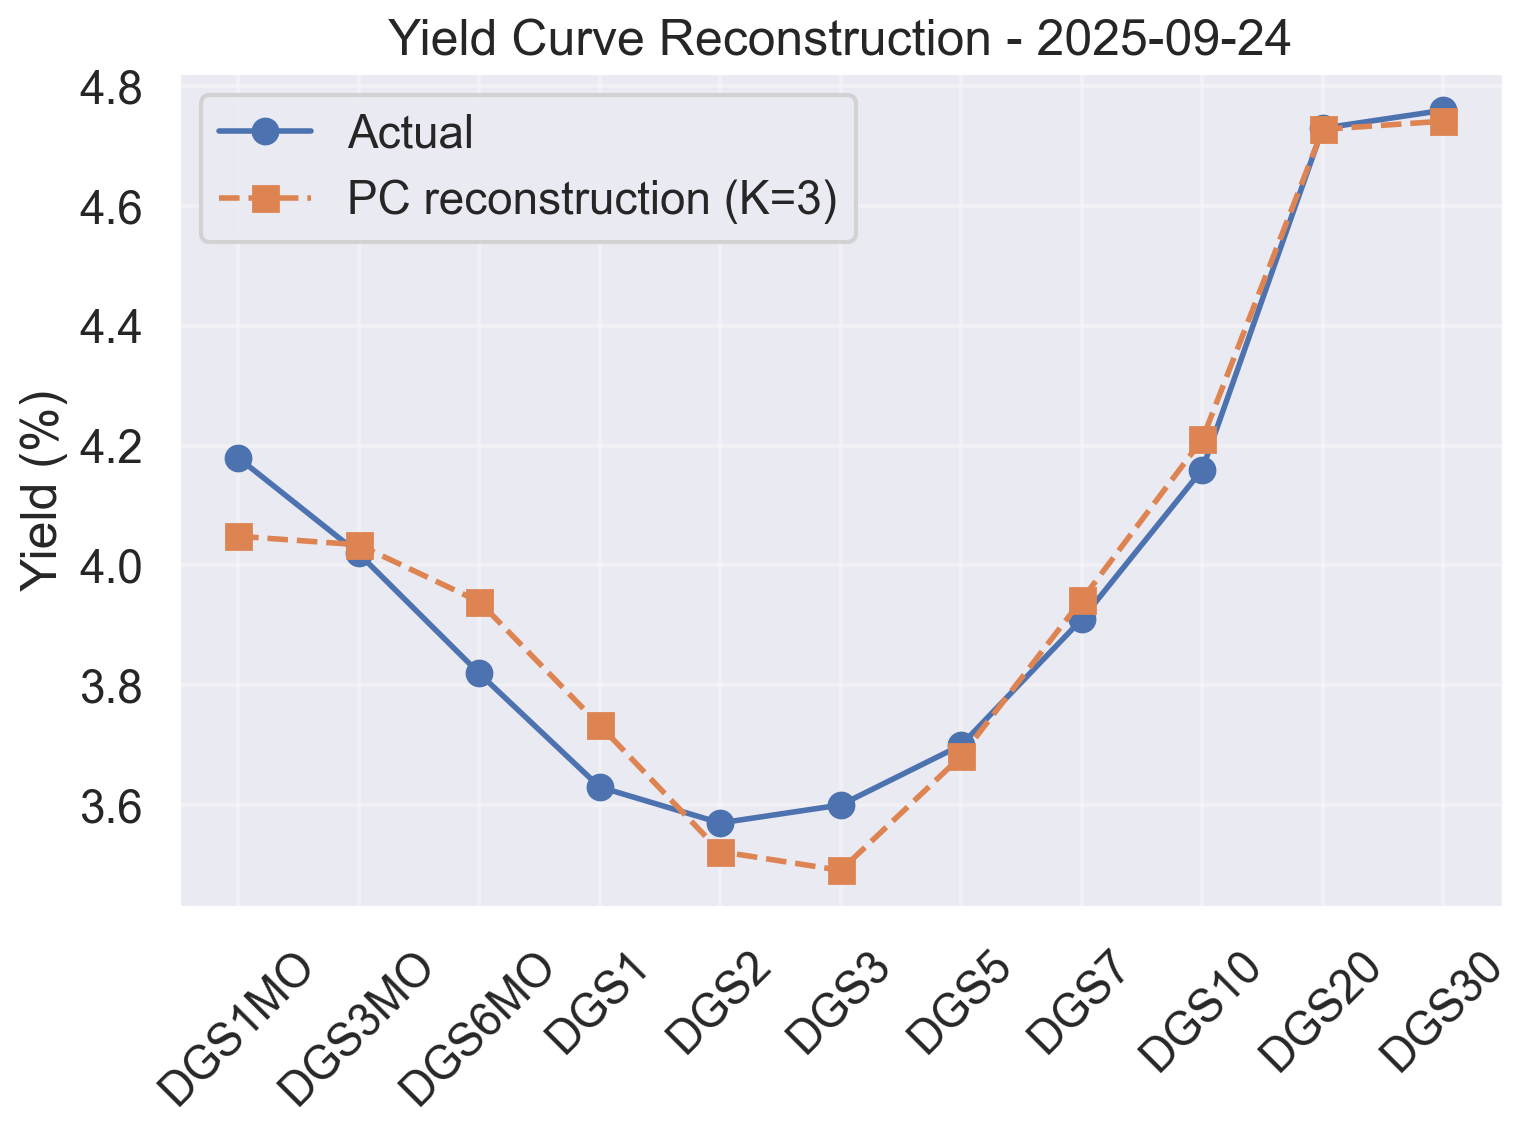

In [ ]:
fig, ax = plt.subplots()
ax.plot(fred_tickers, 100 * y_actual, "o-", label="Actual", linewidth=2)
ax.plot(
    # TODO,
    # TODO,
    "s--",
    label=f"PC reconstruction (K={K})",
    linewidth=2,
)
ax.set_ylabel("Yield (%)")
ax.set_title(f"Yield Curve Reconstruction - {date.strftime('%Y-%m-%d')}")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Reconstruction error

In [ ]:
error = #TODO
print(f"Mean absolute error: {error.mean():.4f}")
print(f"Max absolute error: {error.max():.4f}")

Mean absolute error: 0.0006
Max absolute error: 0.0013
